In [1]:

from google.colab import files
import os
import zipfile

# Upload kaggle.json
print("Upload your kaggle.json file:")
uploaded = files.upload()   # a file picker will appear


Upload your kaggle.json file:


Saving kaggle.json to kaggle.json


In [2]:

# Place it where Kaggle CLI expects it
os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "wb") as f:
    f.write(uploaded["kaggle.json"])
os.chmod("/root/.kaggle/kaggle.json", 0o600)   # required permissions


In [3]:


# Install Kaggle CLI and download the dataset
os.system("pip install -q kaggle")
os.system("kaggle datasets download -d sigfest/database-for-emotion-recognition-system-gameemo")

0

In [4]:
# Unzip
zip_path = "database-for-emotion-recognition-system-gameemo.zip"
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(".")

print("\nDone! Dataset extracted.")
print("Folders found:", [f for f in os.listdir(".") if os.path.isdir(f)])


Done! Dataset extracted.
Folders found: ['.config', 'GAMEEMO', 'sample_data']


In [5]:

!pip install giotto-tda scikit-learn pandas numpy matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 572.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.0/557.0 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 457.9/457.9 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 31.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not cu

In [1]:
import numpy as np
import pandas as pd
import os, glob, warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from gtda.time_series import SingleTakensEmbedding, SlidingWindow
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceEntropy
from gtda.diagrams import Scaler as DiagramScaler


In [2]:
# ── CELL 4: Config ────────────────────────────────────────────────
DATA_DIR = "./GAMEEMO"

CHANNELS = ["AF3","F7","F3","FC5","T7","P7","O1","O2","P8","T8","FC6","F4","F8","AF4"]

EMOTIONS = {"G1": "Boring", "G2": "Calm", "G3": "Horror", "G4": "Funny"}
EMOTION_LABELS = list(EMOTIONS.values())

# Per-channel embedding params — each channel finds its own optimal
# time_delay/dimension via "search", but search runs SEPARATELY on
# the train signal and the test signal (each only sees its own data)
TIME_DELAY = 2   # starting guess for search
DIMENSION  = 3   # starting guess for search

SW_SIZE       = 20
SW_STRIDE     = 10
HOMOLOGY_DIMS = (0, 1)

# Feature budget per channel: 3 lifetime stats (mean/std/max) x 2 homology
# dims + 2 persistence-entropy values (H0, H1) = 8. Betti curve dropped.
FEAT_PER_CHANNEL = 8
N_CHANNELS       = len(CHANNELS)

TEST_SIZE  = 0.2
RANDOM_STATE = 42


In [3]:
#CELL 5: Load one subject's data ───────────────────────────────
def load_subject(subject_id):
    all_X, all_y = [], []

    csv_dir = os.path.join(
        DATA_DIR,
        f"(S{subject_id:02d})",
        "Preprocessed EEG Data",
        ".csv format"
    )

    for game_tag in EMOTIONS:
        label = list(EMOTIONS.keys()).index(game_tag)
        fname = f"S{subject_id:02d}{game_tag}AllChannels.csv"
        fpath = os.path.join(csv_dir, fname)

        if not os.path.exists(fpath):
            print(f"  [warn] not found: {fname}")
            continue

        df   = pd.read_csv(fpath)
        cols = [c for c in df.columns if c in CHANNELS]
        if not cols:
            cols = df.select_dtypes(include=np.number).columns[:14].tolist()

        data = df[cols].values.astype(np.float64) #here data is storing values like just of our dataset total n timestamps in rows and 14 colums, that way only in  numpy ,represmtation different yet all same

        all_X.append(data)                                    # keep as separate block
        all_y.append(np.full(len(data), label, dtype=int))

    if not all_X:
        raise FileNotFoundError(f"No CSVs found for S{subject_id:02d}")

    # Return list of (X_block, y_block) per emotion — NOT concatenated.
    # Concatenating here and splitting 80/20 afterwards would put the
    # entire test set inside the last emotion block (G4/Funny) only.
    return all_X, all_y




In [4]:
# ── CELL 6: Lifetime stats (mean / std / max persistence) ─────────
def persistence_stats(X_pd):
    """
    Compact per-window topological summary. For each homology dimension,
    computes the mean, std, and max of the persistence *lifetimes*
    (death - birth) instead of raw birth/death values.

    Lifetime is the most informative single quantity in a persistence
    diagram: short-lived points are almost always noise, long-lived
    points are the real topological signal. max(lifetime) in particular
    is the "most persistent feature" — a strong, well-known discriminative
    stat in TDA-on-biosignal literature — so it's included alongside the
    mean/std summary.

    Returns (n_windows, 3 * len(HOMOLOGY_DIMS))  ->  (n_windows, 6) here.
    """
    n_windows = X_pd.shape[0]
    all_rows  = []
    for w in range(n_windows):
        row = []
        for dim in HOMOLOGY_DIMS:
            pts    = X_pd[w][X_pd[w, :, 2] == dim]
            finite = pts[np.isfinite(pts[:, 1])]
            if len(finite) == 0:
                row.extend([0.0, 0.0, 0.0])
            else:
                l = finite[:, 1] - finite[:, 0]
                row.extend([l.mean(), l.std(), l.max()])
        all_rows.append(row)
    return np.array(all_rows)
#total n windows. each window- 6 features (3 stats x 2 homology dims).


it is using persisetent homology computed later on. to find out the stats/

In [5]:
# ── CELL 7: TDA features for one channel split ───────────────────
def tda_on_signal(signal, labels):
    """
    Run TDA pipeline on a 1-D signal. Each call independently searches
    for the optimal time_delay/dimension for THIS signal only — so when
    called separately on train and test, there's no leakage between them.

    signal : (T,)
    labels : (T,)

    Returns
    -------
    X_feat : (n_windows, 8)   -- 6 lifetime stats + 2 persistence-entropy
    y_win  : (n_windows,)
    """
    # Step 1 — SingleTakensEmbedding, per-channel optimal params via search.
    # "search" looks ONLY at the signal passed in here — when called on the
    # train split it never sees test data, and vice versa.
    STE = SingleTakensEmbedding(
        parameters_type="search",
        time_delay=TIME_DELAY,
        dimension=DIMENSION,
        n_jobs=-1,#use all cpus.
    )
    X_emb, y_emb = STE.fit_transform_resample(signal, labels)

    # Step 2 — SlidingWindow over embedded point cloud
    SW = SlidingWindow(size=SW_SIZE, stride=SW_STRIDE)
    X_win, y_win = SW.fit_transform_resample(X_emb, y_emb)#x_win.shape has(no of windows,window_size,embedding_dimension)

    # Step 3 — VietorisRipsPersistence
    VR   = VietorisRipsPersistence(homology_dimensions=HOMOLOGY_DIMS, n_jobs=-1)
    X_pd = VR.fit_transform(X_win)
    X_pd = DiagramScaler().fit_transform(X_pd)#
#The persistence diagrams are scaled/normalized.

#This makes the numerical ranges more comparable across different windows before feature extraction. It helps ensure that later features are not dominated simply because one diagram has larger birth/death values than another.

#Notice that the topology (which features exist) does not change—the coordinates are just rescaled.
#

    # Step 4 — Compact feature set: lifetime stats + persistence entropy.
    # Betti curve, amplitude, and number-of-points dropped — they were
    # largely redundant with lifetime/entropy here and just inflated the
    # feature count without adding much discriminative signal.
    feat_life = persistence_stats(X_pd)  # cell-6, (n_win, 6)
    feat_pe   = PersistenceEntropy(normalize=True, nan_fill_value=0.0).fit_transform(X_pd)  # (n_win, 2)

    X_feat = np.hstack([feat_life, feat_pe])   # (n_win, 8)
    return X_feat, y_win


In [6]:
# ── CELL 8: Extract features from one subject ─────────────────────
def extract_subject_features(subject_id):
    """
    Load subject data as separate emotion blocks. For EACH emotion block,
    split 80/20 on its own raw timepoints (so train and test both contain
    all 4 emotions), then run TDA on train and test signals separately.
    Returns pooled train and test feature matrices for this subject.
    """
    blocks_X, blocks_y = load_subject(subject_id)

    # Split each emotion block 80/20 individually, then stitch the splits
    # back together per channel — this keeps the time series CONTIGUOUS
    # within each emotion (needed for Takens embedding) while ensuring
    # both train and test contain samples from all 4 emotions.
    tr_blocks_X, tr_blocks_y = [], []
    te_blocks_X, te_blocks_y = [], []

    for X_block, y_block in zip(blocks_X, blocks_y):
        n = len(y_block)
        split_idx = int(n * 0.8)
        tr_blocks_X.append(X_block[:split_idx])
        tr_blocks_y.append(y_block[:split_idx])
        te_blocks_X.append(X_block[split_idx:])
        te_blocks_y.append(y_block[split_idx:])

    X_tr_all, y_tr_all = [], None
    X_te_all, y_te_all = [], None
    min_tr, min_te     = None, None

    n_channels = blocks_X[0].shape[1]

    for ch_idx in range(n_channels):
        ch = CHANNELS[ch_idx]
        print(f"  S{subject_id:02d} [{ch_idx+1:02d}/14] {ch} ...", end=" ", flush=True)
        try:
            feat_tr_parts, y_tr_parts = [], []
            feat_te_parts, y_te_parts = [], []

            # Run TDA separately on EACH emotion's train slice and test slice,
            # then stack results across emotions for this channel.
            for X_tr_b, y_tr_b, X_te_b, y_te_b in zip(
                tr_blocks_X, tr_blocks_y, te_blocks_X, te_blocks_y
            ):
                f_tr, yw_tr = tda_on_signal(X_tr_b[:, ch_idx], y_tr_b)#has shape(n_win,28),cell7 -called.
                f_te, yw_te = tda_on_signal(X_te_b[:, ch_idx], y_te_b)
                feat_tr_parts.append(f_tr)
                y_tr_parts.append(yw_tr)
                feat_te_parts.append(f_te)
                y_te_parts.append(yw_te)

            # now it has all features of that one channel across all blocks os subject.

            feat_tr = np.vstack(feat_tr_parts)
            #and now they are combined in vertical stack.(for one channel).
            y_tr_win = np.concatenate(y_tr_parts)
            feat_te = np.vstack(feat_te_parts)
            y_te_win = np.concatenate(y_te_parts)

            X_tr_all.append(feat_tr)
            X_te_all.append(feat_te)

            if y_tr_all is None:
                y_tr_all = y_tr_win
                y_te_all = y_te_win
                min_tr   = feat_tr.shape[0]
                min_te   = feat_te.shape[0]
            else:
                min_tr = min(min_tr, feat_tr.shape[0])
                min_te = min(min_te, feat_te.shape[0])

            print(f"tr_wins={feat_tr.shape[0]}, te_wins={feat_te.shape[0]}")
        except Exception as e:
            print(f"SKIPPED — {e}")

    if not X_tr_all:
        return None, None, None, None

    X_tr = np.hstack([f[:min_tr] for f in X_tr_all])
    X_te = np.hstack([f[:min_te] for f in X_te_all])
    y_tr = y_tr_all[:min_tr]
    y_te = y_te_all[:min_te]

    X_tr = np.nan_to_num(X_tr, nan=0.0, posinf=0.0, neginf=0.0)
    X_te = np.nan_to_num(X_te, nan=0.0, posinf=0.0, neginf=0.0)

    return X_tr, y_tr, X_te, y_te

    #now: we jave training feture matrix, training labels, testing feature matrix,testing lables.



first in cell 8 there was vstack of same channel diff block, then different channerls were hstacked.

In [7]:

# ── CELL 9: Confusion matrix plot ─────────────────────────────────
def plot_cm(y_te, y_pred, title):
    cm = confusion_matrix(y_te, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=EMOTION_LABELS,
                yticklabels=EMOTION_LABELS, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


until now we learned how to process: one subject and extracted its features-training and testing...now we will be doing for all subjects

In [8]:

# ── CELL 10: Collect features from all subjects ───────────────────
print("Extracting TDA features from all subjects...")

all_X_tr, all_y_tr = [], []
all_X_te, all_y_te = [], []

for sid in range(1, 5):
    print(f"\n{'='*50}")
    print(f"Subject S{sid:02d}")
    print(f"{'='*50}")
    try:
        X_tr, y_tr, X_te, y_te = extract_subject_features(sid)
        if X_tr is not None:
            all_X_tr.append(X_tr)
            all_y_tr.append(y_tr)
            all_X_te.append(X_te)
            all_y_te.append(y_te)
    except FileNotFoundError as e:
        print(f"  [skip] {e}")
    except Exception as e:
        print(f"  [error] {e}")

# Pool all subjects together
X_train = np.vstack(all_X_tr)
y_train = np.concatenate(all_y_tr)
X_test  = np.vstack(all_X_te)
y_test  = np.concatenate(all_y_te)

print(f"\nTrain : {X_train.shape}  |  Test : {X_test.shape}")


Extracting TDA features from all subjects...

Subject S01
  S01 [01/14] AF3 ... tr_wins=12232, te_wins=3052
  S01 [02/14] F7 ... tr_wins=12232, te_wins=3052
  S01 [03/14] F3 ... tr_wins=12232, te_wins=3052
  S01 [04/14] FC5 ... tr_wins=12232, te_wins=3052
  S01 [05/14] T7 ... tr_wins=12232, te_wins=3052
  S01 [06/14] P7 ... tr_wins=12232, te_wins=3052
  S01 [07/14] O1 ... tr_wins=12232, te_wins=3052
  S01 [08/14] O2 ... tr_wins=12232, te_wins=3052
  S01 [09/14] P8 ... tr_wins=12232, te_wins=3052
  S01 [10/14] T8 ... tr_wins=12232, te_wins=3052
  S01 [11/14] FC6 ... tr_wins=12232, te_wins=3052
  S01 [12/14] F4 ... tr_wins=12232, te_wins=3052
  S01 [13/14] F8 ... tr_wins=12232, te_wins=3052
  S01 [14/14] AF4 ... tr_wins=12232, te_wins=3052

Subject S02
  S02 [01/14] AF3 ... tr_wins=12232, te_wins=3052
  S02 [02/14] F7 ... tr_wins=12232, te_wins=3052
  S02 [03/14] F3 ... tr_wins=12232, te_wins=3052
  S02 [04/14] FC5 ... tr_wins=12232, te_wins=3052
  S02 [05/14] T7 ... tr_wins=12232, te_wi

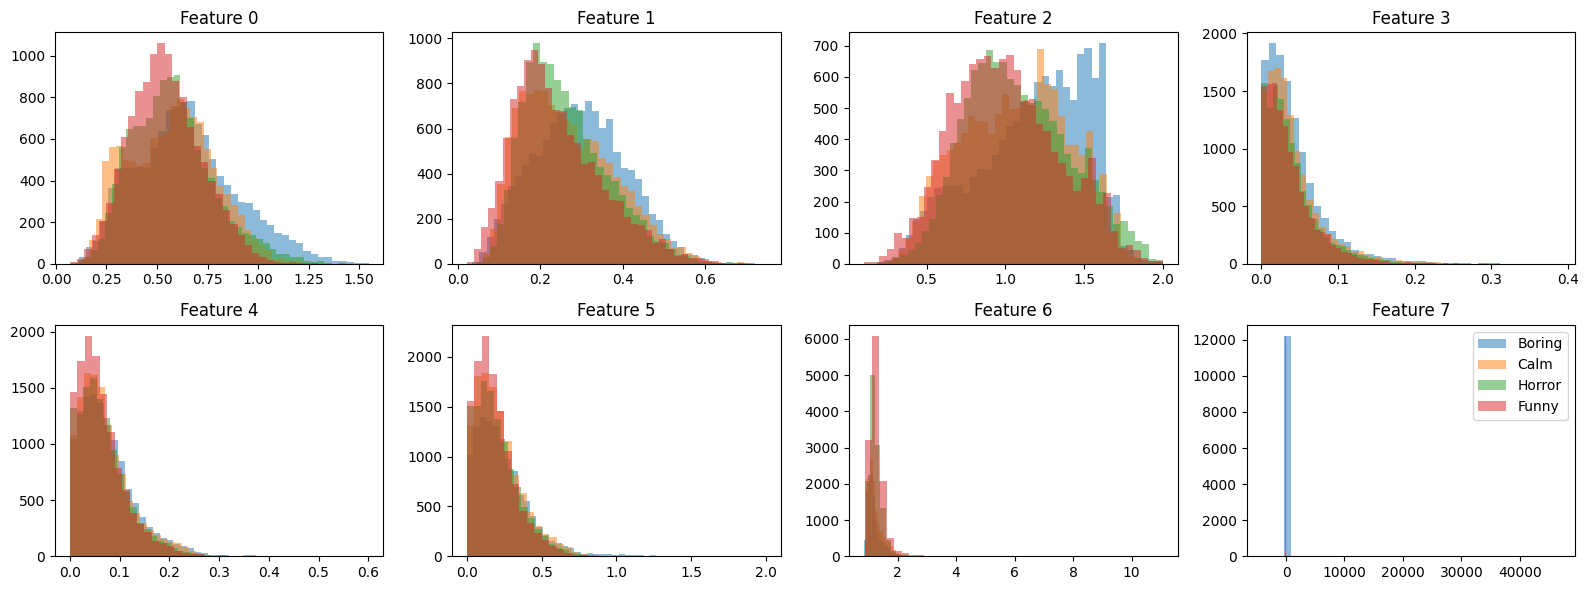

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for i, ax in enumerate(axes.flatten()):
    for cls in range(4):
        vals = X_train[y_train == cls, i]
        ax.hist(vals, bins=40, alpha=0.5, label=EMOTION_LABELS[cls])
    ax.set_title(f"Feature {i}")
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
 #── CELL 11: Scale + reshape for 1D-CNN ────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split as tts

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

assert X_train_sc.shape[1] == N_CHANNELS * FEAT_PER_CHANNEL, \
    f"expected {N_CHANNELS*FEAT_PER_CHANNEL} cols, got {X_train_sc.shape[1]}"

# Reshape (n_windows, 14*8) -> (n_windows, 14, 8) -> (n_windows, 8, 14).
# PyTorch Conv1d expects (batch, in_channels, length); the 8 TDA features
# become the "in_channels" and the 14 EEG electrodes become the spatial
# length the convolution slides across.
def to_cnn_input(X_flat):
    X_r = X_flat.reshape(-1, N_CHANNELS, FEAT_PER_CHANNEL)
    return np.transpose(X_r, (0, 2, 1))   # (n, FEAT_PER_CHANNEL, N_CHANNELS)

X_train_cnn = to_cnn_input(X_train_sc)
X_test_cnn  = to_cnn_input(X_test_sc)

# Carve a validation split OUT OF TRAINING DATA ONLY. Early stopping needs
# to watch a set the model hasn't trained on. Using the real test set for
# that (as before) leaks test-set information into model selection and,
# with only a handful of subjects, gives a noisy signal that doesn't even
# track true generalization. The test set is now touched exactly once,
# at final evaluation in the last cell.
X_tr_cnn, X_val_cnn, y_tr_split, y_val_split = tts(
    X_train_cnn, y_train, test_size=0.15, stratify=y_train, random_state=RANDOM_STATE
)

X_tr_t  = torch.tensor(X_tr_cnn,   dtype=torch.float32)
y_tr_t  = torch.tensor(y_tr_split, dtype=torch.long)
X_val_t = torch.tensor(X_val_cnn,  dtype=torch.float32)
y_val_t = torch.tensor(y_val_split, dtype=torch.long)
X_te_t  = torch.tensor(X_test_cnn, dtype=torch.float32)
y_te_t  = torch.tensor(y_test,     dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                          batch_size=512, shuffle=True)
print(f"train={X_tr_t.shape[0]}  val={X_val_t.shape[0]}  test={X_te_t.shape[0]}")


train=41588  val=7340  test=12208


In [11]:
# ── 1D-CNN definition (v3: channel attention + dual pooling) ──────
class SEBlock1D(nn.Module):
    """
    Squeeze-and-excitation block: learns a per-sample weight for each of
    the 8 TDA-feature 'channels' instead of treating them all equally.
    Cheap (a couple small Linear layers) but lets the net emphasize e.g.
    max-lifetime over entropy for a given window if that's more useful.
    """
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, max(channels // reduction, 4)),
            nn.ReLU(),
            nn.Linear(max(channels // reduction, 4), channels),
            nn.Sigmoid(),
        )

    def forward(self, x):
        # x: (batch, channels, length)
        w = self.pool(x).squeeze(-1)      # (batch, channels)
        w = self.fc(w).unsqueeze(-1)      # (batch, channels, 1)
        return x * w


class TDA_CNN1D(nn.Module):
    def __init__(self, feat_per_channel, n_channels, n_classes=4):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(feat_per_channel, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.4),
        )
        self.se1 = SEBlock1D(32)

        self.conv2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.4),
        )
        self.se2 = SEBlock1D(64)

        # Avg pool captures the "typical" pattern across the 14 electrodes,
        # max pool captures the single strongest activation — concatenating
        # both gives the FC head more to work with than avg alone.
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.max_pool = nn.AdaptiveMaxPool1d(1)

        self.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(64 * 2, 32),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(32, n_classes),
        )

    def forward(self, x):
        # x: (batch, feat_per_channel, n_channels)
        x = self.conv1(x)
        x = self.se1(x)
        x = self.conv2(x)
        x = self.se2(x)
        avg = self.avg_pool(x).flatten(1)
        mx  = self.max_pool(x).flatten(1)
        return self.fc(torch.cat([avg, mx], dim=1))

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


Using device: cpu


In [12]:

model     = TDA_CNN1D(feat_per_channel=FEAT_PER_CHANNEL, n_channels=N_CHANNELS).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=5e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=6, factor=0.5)

NOISE_STD      = 0.05   # Gaussian jitter on standardized features, TRAIN ONLY
CHANNEL_DROP_P = 0.10   # probability of zeroing out a whole EEG electrode, TRAIN ONLY

def channel_dropout(x, p):
    """Randomly zero out whole electrodes (not individual features) per
    sample. Simulates a noisy/disconnected electrode and stops the model
    from over-relying on any single channel — same spirit as the SE block
    above but as a training-time constraint rather than a learned weight."""
    if p <= 0:
        return x
    mask = (torch.rand(x.size(0), 1, x.size(2), device=x.device) > p).float()
    return x * mask

# ── Training loop with early stopping (monitors the VAL split, not test) ──
EPOCHS        = 150   # bumped up — heavier regularization converges slower
PATIENCE      = 15
best_val_acc  = 0.0
best_weights  = None
patience_ctr  = 0

print(f"\nTraining 1D-CNN (early stopping patience={PATIENCE})...")

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        X_batch = X_batch + torch.randn_like(X_batch) * NOISE_STD
        X_batch = channel_dropout(X_batch, CHANNEL_DROP_P)
        optimizer.zero_grad()
        out  = model(X_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        correct    += (out.argmax(1) == y_batch).sum().item()
        total      += len(y_batch)

    # validation every epoch — on the held-out VALIDATION split carved
    # from training data, never the test set
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_t.to(device)).argmax(1).cpu().numpy()
    val_acc   = accuracy_score(y_val_split, val_pred)
    train_acc = correct / total
    scheduler.step(1 - val_acc)

    if epoch % 5 == 0:
        print(f"  Epoch {epoch:03d} — loss={total_loss/total:.4f}, train_acc={train_acc:.4f}, val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"\n  Early stopping at epoch {epoch} — best val_acc={best_val_acc:.4f}")
            break

    model.train()



Training 1D-CNN (early stopping patience=15)...
  Epoch 005 — loss=1.3598, train_acc=0.3196, val_acc=0.3503
  Epoch 010 — loss=1.3297, train_acc=0.3570, val_acc=0.4038
  Epoch 015 — loss=1.2901, train_acc=0.3921, val_acc=0.4525
  Epoch 020 — loss=1.2515, train_acc=0.4259, val_acc=0.5004
  Epoch 025 — loss=1.2170, train_acc=0.4562, val_acc=0.5471
  Epoch 030 — loss=1.1835, train_acc=0.4825, val_acc=0.5790
  Epoch 035 — loss=1.1499, train_acc=0.5099, val_acc=0.6132
  Epoch 040 — loss=1.1266, train_acc=0.5233, val_acc=0.6488
  Epoch 045 — loss=1.0979, train_acc=0.5472, val_acc=0.6797
  Epoch 050 — loss=1.0747, train_acc=0.5635, val_acc=0.6899
  Epoch 055 — loss=1.0630, train_acc=0.5730, val_acc=0.7263
  Epoch 060 — loss=1.0457, train_acc=0.5845, val_acc=0.7360
  Epoch 065 — loss=1.0294, train_acc=0.5940, val_acc=0.7511
  Epoch 070 — loss=1.0173, train_acc=0.6049, val_acc=0.7569
  Epoch 075 — loss=0.9998, train_acc=0.6158, val_acc=0.7717
  Epoch 080 — loss=0.9999, train_acc=0.6183, val_ac


Loaded best model (val_acc=0.8339)

Test Accuracy : 0.3790   (val_acc during training: 0.8339)

              precision    recall  f1-score   support

      Boring       0.38      0.54      0.45      3052
        Calm       0.42      0.46      0.44      3052
      Horror       0.29      0.30      0.30      3052
       Funny       0.47      0.22      0.29      3052

    accuracy                           0.38     12208
   macro avg       0.39      0.38      0.37     12208
weighted avg       0.39      0.38      0.37     12208



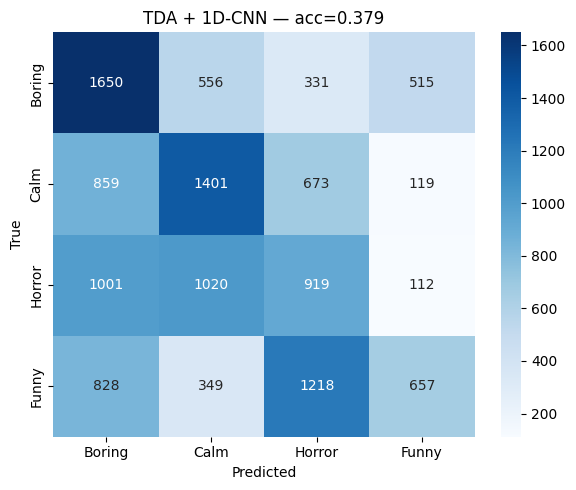

Saved -> tda_cnn_results.csv


In [13]:
# Load best weights before final evaluation
model.load_state_dict(best_weights)
print(f"\nLoaded best model (val_acc={best_val_acc:.4f})")
model.eval()
with torch.no_grad():
    y_pred = model(X_te_t.to(device)).argmax(1).cpu().numpy()

acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy : {acc:.4f}   (val_acc during training: {best_val_acc:.4f})\n")
print(classification_report(y_test, y_pred, target_names=EMOTION_LABELS))

plot_cm(y_test, y_pred, f"TDA + 1D-CNN — acc={acc:.3f}")

pd.DataFrame({"y_true": y_test, "y_pred": y_pred}).to_csv(
    "tda_cnn_results.csv", index=False
)
print("Saved -> tda_cnn_results.csv")


SE(squeeze-excitation)
Input

↓

Global Average Pool

↓

Small MLP

↓

Sigmoid

↓

Importance Scores

↓

Multiply with Original Input

↓

Rescaled Features

..


while in convolution Input

↓

Convolution

↓

New Features